# Notebook for the 1000 Runs Ensemble

In [1]:
import pandas as pd
import os
from utils.eda_utils import EDAUtils
import boto3
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "config")

In [4]:
# Create necessary directories if they don't exist
os.makedirs(DATA_DIR_PATH, exist_ok=True)
os.makedirs(SSP_DIR_PATH, exist_ok=True)
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

In [5]:
edau = EDAUtils()

In [6]:
CONFIG_DIR_PATH

'/Users/alexa/Documents/ssp_uganda_data/metamodel/surrogate_model_sector/config'

## 1) Pull data from AWS S3


In [7]:
config_dict = edau.read_yaml(os.path.join(CONFIG_DIR_PATH, "ml_training_workflow_config.yaml"))
profile_name = config_dict["profile_name"]
bucket_name = config_dict["bucket_name"]
# Set your profile
session = boto3.Session(profile_name=profile_name)

# Create an S3 client or resource
s3 = session.resource('s3')

RUN_ID = config_dict["run_id"]
RUN_ID_DIR_NAME = f"sisepuede_run_{RUN_ID}"

# Define folder prefix
prefix = f'transfers/{RUN_ID_DIR_NAME}/'  # this is like the "folder" in S3

In [9]:
# Local destination
destination = os.path.join(SSP_DIR_PATH, RUN_ID_DIR_NAME)
print(f"Destination path: {destination}")
if os.path.exists(destination) and os.listdir(destination):
    print(f"Destination '{destination}' already exists and is not empty. Skipping download.")
else:
    os.makedirs(destination, exist_ok=True)
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=prefix):
        if obj.key.endswith('/') or "transformations" in obj.key:  # skip directories and transformations
            continue
        target_path = os.path.join(destination, os.path.basename(obj.key))
        print(f"Downloading {obj.key} to {target_path}")
        bucket.download_file(obj.key, target_path)

Destination path: /Users/alexa/Documents/ssp_uganda_data/metamodel/data/ssp/sisepuede_run_2025-11-12t22;19;28.194097


In [10]:
# Set the path to the simulation raw data directory
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, RUN_ID_DIR_NAME)
print(SIMULATION_DIR_PATH)

/Users/alexa/Documents/ssp_uganda_data/metamodel/data/ssp/sisepuede_run_2025-11-12t22;19;28.194097


## 2) Load and Process LHC Samples Dataframes (Our Predictors)

In [11]:
# Load lhc samples dfs
lhs_exogenous_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES.csv"))
lhs_levers_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_LEVER_EFFECTS.csv"))

In [12]:
lhs_exogenous_df.head()

,region,design_id,future_id,60,61,62,63,64,65,66,67,68
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,0.667778
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,0.226586
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,0.154460
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,0.432518
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,0.205513


In [14]:
lhs_levers_df.head()

,region,design_id,future_id,1,2,3,4,5,6,7,...,1711,1712,1714,1726,1727,1730,1731,1733,1735,1736
0,uganda,-1,1,0.101339,0.473404,0.160028,0.138651,0.884491,0.060244,0.020961,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,uganda,-1,2,0.464099,0.820027,0.047124,0.035410,0.611181,0.211565,0.518128,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,uganda,-1,3,0.659192,0.680496,0.143914,0.291818,0.981122,0.678408,0.612630,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,uganda,-1,4,0.398393,0.357480,0.884181,0.014265,0.222220,0.279840,0.861182,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,uganda,-1,5,0.460167,0.770275,0.959465,0.119969,0.735865,0.586344,0.698312,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [15]:
# Add suffix to lever columns to distinguish them later
lhs_levers_df = lhs_levers_df.add_suffix('_L')
lhs_levers_df = lhs_levers_df.rename(columns={"region_L": "region", "design_id_L": "design_id", "future_id_L": "future_id"})
lhs_levers_df.head()

,region,design_id,future_id,1_L,2_L,3_L,4_L,5_L,6_L,7_L,...,1711_L,1712_L,1714_L,1726_L,1727_L,1730_L,1731_L,1733_L,1735_L,1736_L
0,uganda,-1,1,0.101339,0.473404,0.160028,0.138651,0.884491,0.060244,0.020961,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,uganda,-1,2,0.464099,0.820027,0.047124,0.035410,0.611181,0.211565,0.518128,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,uganda,-1,3,0.659192,0.680496,0.143914,0.291818,0.981122,0.678408,0.612630,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,uganda,-1,4,0.398393,0.357480,0.884181,0.014265,0.222220,0.279840,0.861182,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,uganda,-1,5,0.460167,0.770275,0.959465,0.119969,0.735865,0.586344,0.698312,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [16]:
# Add suffix to uncertainties columns to distinguish them later
lhs_exogenous_df = lhs_exogenous_df.add_suffix('_X')
lhs_exogenous_df = lhs_exogenous_df.rename(columns={"region_X": "region", "design_id_X": "design_id", "future_id_X": "future_id"})
lhs_exogenous_df.head()

,region,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,68_X
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,0.667778
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,0.226586
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,0.154460
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,0.432518
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,0.205513


In [17]:
# check unique design ids to ensure they match
print(lhs_exogenous_df.design_id.unique())
print(lhs_levers_df.design_id.unique())

[-1  0  3  4]
[-1  0  3  4]


In [18]:
# print shapes
print(lhs_exogenous_df.shape)
print(lhs_levers_df.shape)

(4000, 12)
(4000, 86)


In [19]:
lhs_df_merged = pd.merge(lhs_exogenous_df, lhs_levers_df, on=["region", "design_id", "future_id"], how="inner")
lhs_df_merged.head()

,region,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,...,1711_L,1712_L,1714_L,1726_L,1727_L,1730_L,1731_L,1733_L,1735_L,1736_L
0,uganda,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,uganda,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,uganda,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,uganda,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,uganda,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [20]:
lhs_df_merged = lhs_df_merged.drop(columns=["region"])
lhs_df_merged.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,1711_L,1712_L,1714_L,1726_L,1727_L,1730_L,1731_L,1733_L,1735_L,1736_L
0,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [21]:
# Check shape
print(lhs_df_merged.shape)

(4000, 94)


In [22]:
# NOTE: check col names, there should be no duplicates
cols = lhs_df_merged.columns
duplicates = cols[cols.duplicated()]
print("Duplicate columns:", list(duplicates))

Duplicate columns: []


In [23]:
lhs_df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 94 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   design_id  4000 non-null   int64  
 1   future_id  4000 non-null   int64  
 2   60_X       4000 non-null   float64
 3   61_X       4000 non-null   float64
 4   62_X       4000 non-null   float64
 5   63_X       4000 non-null   float64
 6   64_X       4000 non-null   float64
 7   65_X       4000 non-null   float64
 8   66_X       4000 non-null   float64
 9   67_X       4000 non-null   float64
 10  68_X       4000 non-null   float64
 11  1_L        4000 non-null   float64
 12  2_L        4000 non-null   float64
 13  3_L        4000 non-null   float64
 14  4_L        4000 non-null   float64
 15  5_L        4000 non-null   float64
 16  6_L        4000 non-null   float64
 17  7_L        4000 non-null   float64
 18  8_L        4000 non-null   float64
 19  9_L        4000 non-null   float64
 20  10_L    

## 3) Load DFs for Target Variable Creation

### Load SISEPUEDE WIDE_INPUTS_OUTPUTS

In [24]:
wide_inputs_outputs_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "sisepuede_results_IDE_2025-11-12t22;19;28.194097.csv"))
wide_inputs_outputs_df

,primary_id,region,time_period,area_agrc_crops_bevs_and_spices,area_agrc_crops_cereals,area_agrc_crops_fibers,area_agrc_crops_fruits,area_agrc_crops_herbs_and_other_perennial_crops,area_agrc_crops_nuts,area_agrc_crops_other_annual,...,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso,design_id,strategy_id,future_id
0,0,uganda,4,634960.593061,2.025945e+06,156073.139455,1.131815e+06,505.429083,5.138329e+05,2.915383e+06,...,2.851485,24.455996,5.111759,5.466143,3.120065,5.679647,7.834200,0,0,0
1,0,uganda,5,640126.452982,2.042427e+06,157342.906406,1.141024e+06,509.541112,5.180133e+05,2.939102e+06,...,2.926134,24.430748,5.280986,5.901251,3.206151,5.860085,7.720287,0,0,0
2,0,uganda,6,642767.262368,2.050853e+06,157992.016628,1.145731e+06,511.643198,5.201503e+05,2.951227e+06,...,2.885015,24.261499,5.471392,6.320646,3.287342,6.163252,7.649363,0,0,0
3,0,uganda,7,645322.479649,2.059006e+06,158620.088334,1.150285e+06,513.677153,5.222181e+05,2.962959e+06,...,2.895205,24.286362,5.674534,6.677825,3.433169,6.497566,7.616672,0,0,0
4,0,uganda,8,647798.760608,2.066907e+06,159228.757514,1.154699e+06,515.648274,5.242220e+05,2.974329e+06,...,2.907203,24.316574,5.906849,6.960800,3.613724,6.869311,7.618560,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103891,375374,uganda,51,780216.190070,2.211158e+06,128906.203719,1.498286e+06,814.896050,1.255106e+06,1.314838e+06,...,3.430064,41.285578,23.598980,4.507728,7.156791,24.652466,6.340611,4,6004,1000
103892,375374,uganda,52,788495.101017,2.233603e+06,130124.813888,1.514142e+06,823.604751,1.269260e+06,1.324660e+06,...,3.369158,41.261605,23.891082,4.624753,7.045961,25.081728,6.143483,4,6004,1000
103893,375374,uganda,53,796799.449638,2.256356e+06,131362.610944,1.529967e+06,832.212225,1.283210e+06,1.335208e+06,...,3.306374,41.234818,24.188186,4.709914,6.941360,25.517470,5.941191,4,6004,1000
103894,375374,uganda,54,805118.957301,2.279368e+06,132613.252754,1.545746e+06,840.714329,1.296978e+06,1.346316e+06,...,3.241627,41.204897,24.490275,4.763500,6.843516,25.959593,5.734102,4,6004,1000


In [25]:
wide_inputs_outputs_df.primary_id.nunique()

1998

In [26]:
# add year column
wide_inputs_outputs_df["year"] = wide_inputs_outputs_df["time_period"] + 2015

### Load CB Wide File

In [27]:
cb_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "wide_cb_data_lhc_sisepuede_run_2025-11-12t22;19;28.194097.csv"))
cb_df

,primary_id,future_id,strategy_code,Year,air_pollution,congestion,consumer_savings,crop_value,ecosystem_services,env_pollution,...,human_health,ippu_value,land_pollution,lvst_value,road_safety,sector_specific,system_cost,technical_cost,technical_savings,water_pollution
0,1001,0,AGRC:DEC_CH4_RICE,2019,0.0,0.0,NaN,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,0.0
1,1001,0,AGRC:DEC_CH4_RICE,2020,0.0,0.0,NaN,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,0.0
2,1001,0,AGRC:DEC_CH4_RICE,2021,0.0,0.0,NaN,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,0.0
3,1001,0,AGRC:DEC_CH4_RICE,2022,0.0,0.0,NaN,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,0.0
4,1001,0,AGRC:DEC_CH4_RICE,2023,0.0,0.0,NaN,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103839,375374,1000,PFLO:NZ,2066,NaN,NaN,29.128911,NaN,NaN,NaN,...,17.906486,NaN,NaN,NaN,NaN,NaN,NaN,-1.756948,NaN,NaN
103840,375374,1000,PFLO:NZ,2067,NaN,NaN,30.275406,NaN,NaN,NaN,...,18.583429,NaN,NaN,NaN,NaN,NaN,NaN,-1.828242,NaN,NaN
103841,375374,1000,PFLO:NZ,2068,NaN,NaN,31.443209,NaN,NaN,NaN,...,19.270369,NaN,NaN,NaN,NaN,NaN,NaN,-1.901486,NaN,NaN
103842,375374,1000,PFLO:NZ,2069,NaN,NaN,32.632247,NaN,NaN,NaN,...,19.966958,NaN,NaN,NaN,NaN,NaN,NaN,-1.976759,NaN,NaN


In [28]:
# Make fiel names lower case
cb_df.columns = cb_df.columns.str.lower()

In [29]:
print("cb_df shape:", cb_df.shape)
print("cb_unique primary_id count:", cb_df.primary_id.nunique())

cb_df shape: (103844, 21)
cb_unique primary_id count: 1997


In [30]:
#cb_df shape: (103844, 21)
#cb_unique primary_id count: 1997

## 4) Data Prep

### SISEPUEDE Emission data

We want to get the subsector totals to then sum them up and compute the economy-wide emissions total

In [31]:
# Get the subsector total variables
subsector_total_vars = [c for c in wide_inputs_outputs_df.columns if "emission_co2e_subsector_total" in c]

In [32]:
# Filter to only subsector total columns and primary_id, year
la_emissions_df = wide_inputs_outputs_df[["primary_id", "year"] + subsector_total_vars]
la_emissions_df.head()

,primary_id,year,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
0,0,2019,2.149236,0.0,50.251724,0.000000e+00,-10.894251,4.042769,0.369457,12.786390,2.851485,24.455996,5.111759,5.466143,3.120065,5.679647,7.834200
1,0,2020,2.231574,0.0,50.438607,0.000000e+00,-10.930650,4.144474,0.431364,14.592304,2.926134,24.430748,5.280986,5.901251,3.206151,5.860085,7.720287
2,0,2021,2.361532,0.0,49.334470,0.000000e+00,-10.864787,3.876473,0.487391,14.491826,2.885015,24.261499,5.471392,6.320646,3.287342,6.163252,7.649363
3,0,2022,2.366993,0.0,50.653396,0.000000e+00,-10.798336,3.796968,0.497802,14.390979,2.895205,24.286362,5.674534,6.677825,3.433169,6.497566,7.616672
4,0,2023,2.397417,0.0,52.081951,4.313241e-20,-10.731444,3.683509,0.505170,14.286685,2.907203,24.316574,5.906849,6.960800,3.613724,6.869311,7.618560


In [33]:
la_emissions_df.tail()

,primary_id,year,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso
103891,375374,2066,5.658820,-0.257085,4.186917,0.000113,-12.050530,6.414576,0.383571,10.755071,3.430064,41.285578,23.598980,4.507728,7.156791,24.652466,6.340611
103892,375374,2067,5.767302,-0.263677,4.241932,0.000113,-11.811217,6.429844,0.376376,11.075056,3.369158,41.261605,23.891082,4.624753,7.045961,25.081728,6.143483
103893,375374,2068,5.875665,-0.270269,4.296581,0.000113,-11.569031,6.446790,0.369181,11.366478,3.306374,41.234818,24.188186,4.709914,6.941360,25.517470,5.941191
103894,375374,2069,5.983862,-0.276860,4.350721,0.000113,-11.324813,6.465401,0.361973,11.632178,3.241627,41.204897,24.490275,4.763500,6.843516,25.959593,5.734102
103895,375374,2070,6.091366,-0.283452,4.404336,0.000113,-11.079211,6.485681,0.354738,11.401411,3.174863,41.171908,24.797897,4.775873,6.752535,26.409307,5.522618


In [34]:
# Sum all the subsector emission columns across axis=1
la_emission_total_df = la_emissions_df.copy()
la_emission_total_df["emission_total"] = la_emission_total_df[subsector_total_vars].sum(axis=1)
la_emission_total_df.head()

,primary_id,year,emission_co2e_subsector_total_agrc,emission_co2e_subsector_total_ccsq,emission_co2e_subsector_total_entc,emission_co2e_subsector_total_fgtv,emission_co2e_subsector_total_frst,emission_co2e_subsector_total_inen,emission_co2e_subsector_total_ippu,emission_co2e_subsector_total_lndu,emission_co2e_subsector_total_lsmm,emission_co2e_subsector_total_lvst,emission_co2e_subsector_total_scoe,emission_co2e_subsector_total_soil,emission_co2e_subsector_total_trns,emission_co2e_subsector_total_trww,emission_co2e_subsector_total_waso,emission_total
0,0,2019,2.149236,0.0,50.251724,0.000000e+00,-10.894251,4.042769,0.369457,12.786390,2.851485,24.455996,5.111759,5.466143,3.120065,5.679647,7.834200,113.224620
1,0,2020,2.231574,0.0,50.438607,0.000000e+00,-10.930650,4.144474,0.431364,14.592304,2.926134,24.430748,5.280986,5.901251,3.206151,5.860085,7.720287,116.233315
2,0,2021,2.361532,0.0,49.334470,0.000000e+00,-10.864787,3.876473,0.487391,14.491826,2.885015,24.261499,5.471392,6.320646,3.287342,6.163252,7.649363,115.725414
3,0,2022,2.366993,0.0,50.653396,0.000000e+00,-10.798336,3.796968,0.497802,14.390979,2.895205,24.286362,5.674534,6.677825,3.433169,6.497566,7.616672,117.989134
4,0,2023,2.397417,0.0,52.081951,4.313241e-20,-10.731444,3.683509,0.505170,14.286685,2.907203,24.316574,5.906849,6.960800,3.613724,6.869311,7.618560,120.416309


In [35]:
# Keep only the primary_id, time_period, and emission_total columns
la_emission_total_df = la_emission_total_df[["primary_id", "year", "emission_total"]]

la_emission_total_df.head()

,primary_id,year,emission_total
0,0,2019,113.224620
1,0,2020,116.233315
2,0,2021,115.725414
3,0,2022,117.989134
4,0,2023,120.416309


In [36]:
la_emission_total_df.tail()

,primary_id,year,emission_total
103891,375374,2066,126.063671
103892,375374,2067,127.233500
103893,375374,2068,128.354821
103894,375374,2069,129.430084
103895,375374,2070,129.979982


In [37]:
totals = (
    la_emission_total_df
    .groupby("primary_id", as_index=False)["emission_total"]
    .sum()
    .rename(columns={"emission_total": "emission_total_sum"})
)

In [38]:
yrs = (
    la_emission_total_df[la_emission_total_df["year"].isin(np.arange(2033, 2071))]
    .pivot_table(
        index="primary_id",
        columns="year",
        values="emission_total",
        aggfunc="sum"   # in case you have duplicates
    )
    .reset_index()
)

yrs["2033_2037_mean_emission"] = np.mean(yrs[np.arange(2033, 2038)], axis=1)
yrs["2066_2070_mean_emission"] = np.mean(yrs[np.arange(2066, 2071)], axis=1)
yrs = yrs[["primary_id", "2033_2037_mean_emission", "2066_2070_mean_emission"]]

yrs.head()

year,primary_id,2033_2037_mean_emission,2066_2070_mean_emission
0,0,169.121867,293.599699
1,1001,169.121867,293.599699
2,2002,169.121867,293.599699
3,3003,169.121867,293.599699
4,4004,169.121867,293.599699


In [39]:
# gdp = (
#     la_emission_total_df[la_emission_total_df["year"].isin(np.arange(2025, 2071))]
#     .pivot_table(
#         index="primary_id",
#         columns="year",
#         values="gdp_mmm_usd",
#         aggfunc="sum"
#     )
#     .reset_index()
# )

In [40]:
# gdp["2025_2035_gdp"] = gdp[np.arange(2025,2036)].sum(axis=1)
# gdp["2025_2070_gdp"] = gdp[np.arange(2025,2071)].sum(axis=1)
# gdp = gdp[["primary_id", "2025_2035_gdp", "2025_2070_gdp"]]
# gdp.head()

In [41]:
la_emission_df_sum_agg = totals.merge(yrs, on="primary_id", how="left") #.merge(gdp, on="primary_id", how="left")

In [42]:
la_emission_df_sum_agg.head()

,primary_id,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission
0,0,10256.854756,169.121867,293.599699
1,1001,10256.854756,169.121867,293.599699
2,2002,10256.854756,169.121867,293.599699
3,3003,10256.854756,169.121867,293.599699
4,4004,10256.854756,169.121867,293.599699


In [43]:
la_emission_df_sum_agg.tail()

,primary_id,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission
1993,375370,5681.745622,128.451229,98.070206
1994,375371,6006.431749,124.390629,119.987734
1995,375372,6612.181768,132.930773,139.550386
1996,375373,5491.884219,126.989945,88.298812
1997,375374,6402.351627,141.186126,128.212412


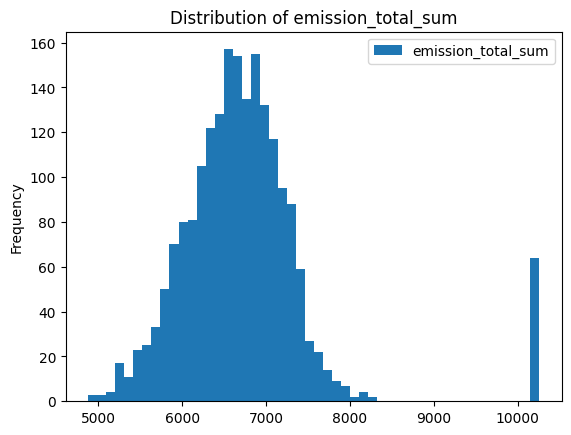

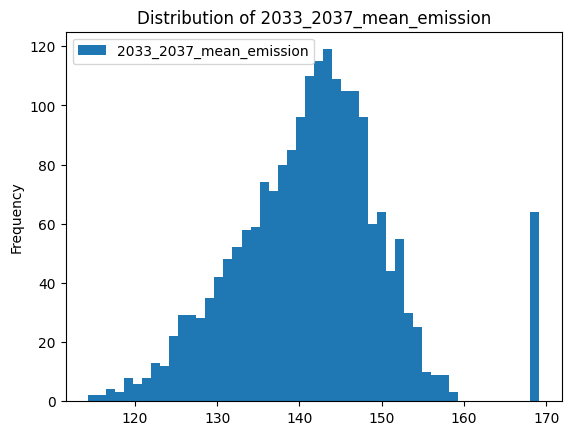

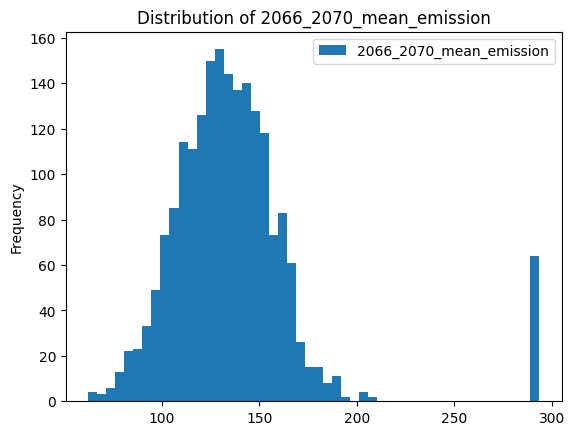

In [44]:
# Check distribution of emission_total
for field in la_emission_df_sum_agg.columns:
    if field == "primary_id":
        continue

    la_emission_df_sum_agg.plot(kind='hist', y=field, bins=50, title=f'Distribution of {field}')


In [45]:
# Print shape
print(la_emission_df_sum_agg.shape)
print(la_emission_df_sum_agg.primary_id.nunique())

(1998, 4)
1998


### CB data

We want to fill nulls with zeros and aggregate the cost fields to have single records per primary id

In [46]:
cb_df.head()

,primary_id,future_id,strategy_code,year,air_pollution,congestion,consumer_savings,crop_value,ecosystem_services,env_pollution,...,human_health,ippu_value,land_pollution,lvst_value,road_safety,sector_specific,system_cost,technical_cost,technical_savings,water_pollution
0,1001,0,AGRC:DEC_CH4_RICE,2019,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
1,1001,0,AGRC:DEC_CH4_RICE,2020,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
2,1001,0,AGRC:DEC_CH4_RICE,2021,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
3,1001,0,AGRC:DEC_CH4_RICE,2022,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
4,1001,0,AGRC:DEC_CH4_RICE,2023,0.0,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


In [47]:
cb_df.isnull().sum()

primary_id                 0
future_id                  0
strategy_code              0
year                       0
air_pollution         100516
congestion            100516
consumer_savings        3120
crop_value            100516
ecosystem_services    100516
env_pollution         100516
fuel_cost             100516
human_health               0
ippu_value            100516
land_pollution        100516
lvst_value            100516
road_safety           100516
sector_specific       100516
system_cost           100516
technical_cost             0
technical_savings     103376
water_pollution       100516
dtype: int64

In [48]:
cb_df = cb_df.fillna(0)
cb_df.isnull().sum()

primary_id            0
future_id             0
strategy_code         0
year                  0
air_pollution         0
congestion            0
consumer_savings      0
crop_value            0
ecosystem_services    0
env_pollution         0
fuel_cost             0
human_health          0
ippu_value            0
land_pollution        0
lvst_value            0
road_safety           0
sector_specific       0
system_cost           0
technical_cost        0
technical_savings     0
water_pollution       0
dtype: int64

In [49]:
cb_df.columns

Index(['primary_id', 'future_id', 'strategy_code', 'year', 'air_pollution',
       'congestion', 'consumer_savings', 'crop_value', 'ecosystem_services',
       'env_pollution', 'fuel_cost', 'human_health', 'ippu_value',
       'land_pollution', 'lvst_value', 'road_safety', 'sector_specific',
       'system_cost', 'technical_cost', 'technical_savings',
       'water_pollution'],
      dtype='object')

In [50]:
cb_df = cb_df.drop(columns=["strategy_code", "future_id"])

In [51]:
cb_df

,primary_id,year,air_pollution,congestion,consumer_savings,crop_value,ecosystem_services,env_pollution,fuel_cost,human_health,ippu_value,land_pollution,lvst_value,road_safety,sector_specific,system_cost,technical_cost,technical_savings,water_pollution
0,1001,2019,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,1001,2020,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,1001,2021,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,1001,2022,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,1001,2023,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103839,375374,2066,0.0,0.0,29.128911,0.0,0.0,0.0,0.0,17.906486,0.0,0.0,0.0,0.0,0.0,0.0,-1.756948,0.0,0.0
103840,375374,2067,0.0,0.0,30.275406,0.0,0.0,0.0,0.0,18.583429,0.0,0.0,0.0,0.0,0.0,0.0,-1.828242,0.0,0.0
103841,375374,2068,0.0,0.0,31.443209,0.0,0.0,0.0,0.0,19.270369,0.0,0.0,0.0,0.0,0.0,0.0,-1.901486,0.0,0.0
103842,375374,2069,0.0,0.0,32.632247,0.0,0.0,0.0,0.0,19.966958,0.0,0.0,0.0,0.0,0.0,0.0,-1.976759,0.0,0.0


In [52]:
cost_fields = [col for col in cb_df.columns if "cost" in col]
cost_fields

['fuel_cost', 'system_cost', 'technical_cost']

In [53]:
benefit_fields = [col for col in cb_df.columns if not col in cost_fields and col not in ["primary_id", "year"]]
benefit_fields

['air_pollution',
 'congestion',
 'consumer_savings',
 'crop_value',
 'ecosystem_services',
 'env_pollution',
 'human_health',
 'ippu_value',
 'land_pollution',
 'lvst_value',
 'road_safety',
 'sector_specific',
 'technical_savings',
 'water_pollution']

In [ ]:
# Keep all benefit types disaggregated (do NOT sum into total_benefits).
# Raw convention is already diverging: benefits positive, costs negative cash
# flows — so we keep raw signs (no negation) for the cost/benefit chart.
cb_df.head()

In [55]:
#NOTE: For now i will only use technical cost and system cost
cb_df.describe()

,primary_id,year,fuel_cost,system_cost,technical_cost,total_benefits
count,103844.000000,103844.000000,103844.000000,103844.000000,103844.000000,1.038440e+05
mean,327152.192288,2044.500000,0.000222,-0.000004,-0.917542,1.788185e+01
std,65249.799468,15.008403,0.012467,0.001517,0.843362,1.610932e+01
min,1001.000000,2019.000000,0.000000,-0.127115,-30.616897,-9.206553e-15
25%,298751.000000,2031.750000,0.000000,0.000000,-1.462669,3.011834e+00
50%,299266.000000,2044.500000,0.000000,0.000000,-0.757342,1.386661e+01
75%,374859.000000,2057.250000,0.000000,0.000000,-0.232072,3.025076e+01
max,375374.000000,2070.000000,0.887930,0.095608,0.455269,6.670100e+01


In [ ]:
# (Costs kept disaggregated and negated above — no technical/system merge, fuel retained.)

In [57]:
cb_df = cb_df.merge(wide_inputs_outputs_df[["primary_id", "year", "gdp_mmm_usd"]], how="left", on=["primary_id", "year"])
cb_df

,primary_id,year,technical_cost,total_benefits,gdp_mmm_usd
0,1001,2019,-0.000000,0.000000,96.640000
1,1001,2020,-0.000000,0.000000,99.490000
2,1001,2021,-0.000000,0.000000,103.010000
3,1001,2022,-0.000000,0.000000,107.730000
4,1001,2023,-0.000000,0.000000,113.483902
...,...,...,...,...,...
103839,375374,2066,1.756948,47.035397,681.037974
103840,375374,2067,1.828242,48.858835,693.270521
103841,375374,2068,1.901486,50.713578,705.886540
103842,375374,2069,1.976759,52.599205,718.893701


In [ ]:
# (Per-year cost-as-%-of-GDP is computed in the chatbot from the gdp_mmm_usd_yr* targets.)

In [59]:
cb_df.tail()

,primary_id,year,technical_cost,total_benefits,gdp_mmm_usd,technical_cost_relative_to_gdp
103839,375374,2066,1.756948,47.035397,681.037974,0.002580
103840,375374,2067,1.828242,48.858835,693.270521,0.002637
103841,375374,2068,1.901486,50.713578,705.886540,0.002694
103842,375374,2069,1.976759,52.599205,718.893701,0.002750
103843,375374,2070,2.054242,54.519062,732.299827,0.002805


In [60]:
1.756948/681.037974

0.0025798091546654343

In [ ]:
# ── Disaggregated cost & benefit targets (per type × per year) ─────────────
# Replaces the old aggregate cost/benefit metrics. Keep every benefit type
# (positive) and every cost type (negative, negated above), pivoted to the 4
# reporting years. GDP per year is added so the chatbot can compute
# cost-as-%-of-GDP = total_cost / gdp at each year.
TARGET_YEARS = [2030, 2040, 2050, 2070]
cb_year = cb_df[cb_df["year"].isin(TARGET_YEARS)]

frames = []
for field in benefit_fields:                       # 14 benefit types (positive)
    piv = cb_year.pivot_table(index="primary_id", columns="year", values=field, aggfunc="sum")
    piv.columns = [f"benefit_{field}_yr{int(yr)}" for yr in piv.columns]
    frames.append(piv)

for field in cost_fields:                           # 3 cost types (negative)
    label = field.replace("_cost", "")              # technical / system / fuel
    piv = cb_year.pivot_table(index="primary_id", columns="year", values=field, aggfunc="sum")
    piv.columns = [f"cost_{label}_yr{int(yr)}" for yr in piv.columns]
    frames.append(piv)

piv = cb_year.pivot_table(index="primary_id", columns="year", values="gdp_mmm_usd", aggfunc="sum")
piv.columns = [f"gdp_mmm_usd_yr{int(yr)}" for yr in piv.columns]
frames.append(piv)

cb_df_agg = pd.concat(frames, axis=1).reset_index()
print("cb_df_agg shape:", cb_df_agg.shape)          # primary_id + 56 + 12 + 4 = 73
cb_df_agg.head()

In [ ]:
# (removed — replaced by the disaggregated cost/benefit builder above)

In [ ]:
# (removed — replaced by the disaggregated cost/benefit builder above)

In [ ]:
# (removed — replaced by the disaggregated cost/benefit builder above)

In [ ]:
# (removed — replaced by the disaggregated cost/benefit builder above)

In [ ]:
# (removed — replaced by the disaggregated cost/benefit builder above)

In [ ]:
# (removed — replaced by the disaggregated cost/benefit builder above)

In [ ]:
# (removed — replaced by the disaggregated cost/benefit builder above)

## 5) Merge emissions df with lhs samples df

In [69]:
attr_primary_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
attr_primary_df

,primary_id,design_id,strategy_id,future_id
0,0,0,0,0
1,70070,0,6004,0
2,74074,0,6008,0
3,75075,0,6009,0
4,298299,3,6004,1
...,...,...,...,...
2062,62062,0,4003,0
2063,63063,0,4004,0
2064,64064,0,4005,0
2065,66066,0,6000,0


In [70]:
# Check for duplicates in primary_id
duplicates_primary = attr_primary_df[attr_primary_df.duplicated(subset=["primary_id"], keep=False)]
if not duplicates_primary.empty:
    print("Duplicated primary_id found:")
    print(duplicates_primary)
else:
    print("No duplicated primary_id found.")

No duplicated primary_id found.


In [71]:
# Merge emissions df with the attribute primary df filtered
la_emission_df_w_future_id = la_emission_df_sum_agg.merge(attr_primary_df, on="primary_id", how="inner")

la_emission_df_w_future_id.head()

,primary_id,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,design_id,strategy_id,future_id
0,0,10256.854756,169.121867,293.599699,0,0,0
1,1001,10256.854756,169.121867,293.599699,0,1000,0
2,2002,10256.854756,169.121867,293.599699,0,1001,0
3,3003,10256.854756,169.121867,293.599699,0,1002,0
4,4004,10256.854756,169.121867,293.599699,0,1003,0


In [72]:
# Check shape of the merged df
print(la_emission_df_sum_agg.shape)
print(la_emission_df_w_future_id.shape)

(1998, 4)
(1998, 7)


In [73]:
# Merge with cb data
la_emission_df_w_future_id_cb = la_emission_df_w_future_id.merge(cb_df_agg, on=["primary_id"], how="inner")
la_emission_df_w_future_id_cb.head()

,primary_id,emission_total_sum,2033_2037_mean_emission,2066_2070_mean_emission,design_id,strategy_id,future_id,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,1001,10256.854756,169.121867,293.599699,0,1000,0,0.0,0.0,0.000853,0.003609,0.000005,0.000008,0.000004,0.000006
1,2002,10256.854756,169.121867,293.599699,0,1001,0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3003,10256.854756,169.121867,293.599699,0,1002,0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4004,10256.854756,169.121867,293.599699,0,1003,0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,5005,10256.854756,169.121867,293.599699,0,1004,0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [74]:
print("cb df_agg shape:", cb_df_agg.shape)
print("la_emission_df_w_future_id_cb shape:", la_emission_df_w_future_id_cb.shape)

cb df_agg shape: (1997, 9)
la_emission_df_w_future_id_cb shape: (1997, 15)


In [75]:
lhs_df_merged.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,1711_L,1712_L,1714_L,1726_L,1727_L,1730_L,1731_L,1733_L,1735_L,1736_L
0,-1,1,0.547746,0.784382,0.142538,0.798656,0.138570,0.461001,0.760845,0.677736,...,0.688639,0.596966,0.834522,0.330330,0.044224,0.032135,0.182714,0.844836,0.498520,0.772983
1,-1,2,0.104242,0.871744,0.885693,0.731615,0.393896,0.254986,0.388944,0.079108,...,0.148571,0.234722,0.931380,0.967060,0.313207,0.292206,0.162030,0.960173,0.768682,0.661526
2,-1,3,0.450676,0.745613,0.955297,0.108820,0.299103,0.962902,0.367651,0.181581,...,0.868888,0.465322,0.621219,0.526694,0.292932,0.974558,0.573934,0.131377,0.932751,0.807064
3,-1,4,0.793911,0.915802,0.259297,0.303791,0.188833,0.473412,0.973142,0.756275,...,0.756216,0.421172,0.749805,0.573124,0.726761,0.899023,0.904114,0.838549,0.512434,0.040781
4,-1,5,0.781801,0.126404,0.934463,0.344480,0.277149,0.441921,0.477712,0.973170,...,0.161908,0.605281,0.331478,0.580207,0.030258,0.170369,0.632889,0.121736,0.652663,0.567400


In [76]:
# Merge emissions data with lhs data
lhs_emissions_merged_df = pd.merge(lhs_df_merged, la_emission_df_w_future_id_cb, on=["design_id", "future_id"], how="inner")
lhs_emissions_merged_df.head()

,design_id,future_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,2066_2070_mean_emission,strategy_id,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,3,1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,162.178247,6004,2.934405,19.269972,0.448135,0.834822,0.003210,0.003797,0.002197,0.001412
1,3,2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,165.491078,6004,3.086639,20.875301,0.450949,1.094102,0.003223,0.004213,0.002211,0.001851
2,3,3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,167.532309,6004,3.027576,20.253282,0.455116,0.946547,0.003264,0.003950,0.002231,0.001601
3,3,4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,171.095935,6004,3.027648,20.315354,0.473642,1.031214,0.003431,0.004125,0.002322,0.001745
4,3,5,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,152.521376,6004,3.009067,20.038498,0.420872,0.882343,0.002963,0.003828,0.002063,0.001493


In [77]:
print("lhs_df_merged shape:", lhs_df_merged.shape)
print("la_emission_df_w_future_id_cb shape:", la_emission_df_w_future_id_cb.shape)
print("lhs_emissions_merged_df shape:", lhs_emissions_merged_df.shape)

lhs_df_merged shape: (4000, 94)
la_emission_df_w_future_id_cb shape: (1997, 15)
lhs_emissions_merged_df shape: (1933, 107)


In [78]:
# rearrange columns to have future_id and primary_id at the front
cols_order = ["future_id", "primary_id"] + [col for col in lhs_emissions_merged_df.columns if col not in ["future_id", "primary_id"]]
lhs_emissions_merged_df = lhs_emissions_merged_df[cols_order]
lhs_emissions_merged_df

,future_id,primary_id,design_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,...,2066_2070_mean_emission,strategy_id,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,1,298299,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,162.178247,6004,2.934405,19.269972,0.448135,0.834822,0.003210,0.003797,0.002197,0.001412
1,2,298300,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,165.491078,6004,3.086639,20.875301,0.450949,1.094102,0.003223,0.004213,0.002211,0.001851
2,3,298301,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,167.532309,6004,3.027576,20.253282,0.455116,0.946547,0.003264,0.003950,0.002231,0.001601
3,4,298302,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,171.095935,6004,3.027648,20.315354,0.473642,1.031214,0.003431,0.004125,0.002322,0.001745
4,5,298303,3,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,152.521376,6004,3.009067,20.038498,0.420872,0.882343,0.002963,0.003828,0.002063,0.001493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1928,996,375370,4,0.059039,0.417728,0.091020,0.318165,0.645634,0.513777,0.574314,...,98.070206,6004,3.143118,21.432413,0.449608,1.103491,0.004721,0.005945,0.002808,0.003062
1929,997,375371,4,0.461471,0.491210,0.210822,0.844321,0.633153,0.599206,0.763054,...,119.987734,6004,3.158001,21.383862,0.430253,1.059700,0.004202,0.005680,0.002593,0.002712
1930,998,375372,4,0.723537,0.180950,0.551961,0.158086,0.882026,0.818294,0.505303,...,139.550386,6004,3.174055,22.051566,0.446714,1.143161,0.003781,0.005087,0.002449,0.002395
1931,999,375373,4,0.479683,0.722598,0.275481,0.613768,0.764342,0.850816,0.851390,...,88.298812,6004,3.135014,21.528305,0.444138,0.989773,0.004231,0.005162,0.002627,0.002431


In [79]:
# Drop some unnecessary columns
lhs_emissions_merged_df = lhs_emissions_merged_df.drop(columns=["design_id",
                                                                "strategy_id"])

In [80]:
# Check for nans
lhs_emissions_merged_df.isna().sum().sum()

np.int64(0)

## Filter out irrelevant lhs groups

In [81]:
var_traj_X_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_X.csv"))
var_traj_L_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L.csv"))

In [82]:
# add suffix to items in variable_trajectory_group field items
var_traj_X_df["variable_trajectory_group_w_suffix"] = var_traj_X_df["variable_trajectory_group"].astype(str) + '_X'
var_traj_X_df.tail()

,variable,variable_trajectory_group,variable_trajectory_group_w_suffix
54,elasticity_scoe_enerdem_per_hh_residential_ele...,66,66_X
55,elasticity_scoe_enerdem_per_hh_residential_hea...,66,66_X
56,elasticity_trde_mtkm_to_gdp_freight,67,67_X
57,elasticity_trde_pkm_to_gdppc_private_and_public,68,68_X
58,elasticity_trde_pkm_to_gdppc_regional,68,68_X


In [83]:
# add suffix to items in variable_trajectory_group field items
var_traj_L_df["variable_trajectory_group_w_suffix"] = var_traj_L_df["variable_trajectory_group"].astype(str) + '_L'
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group,variable_trajectory_group_w_suffix
558,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_paper,59,59_L
559,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_plastic,59,59_L
560,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,59,59_L
561,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_textiles,59,59_L
562,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_wood,59,59_L


In [84]:
var_traj_groups_X = var_traj_X_df["variable_trajectory_group_w_suffix"].unique()
var_traj_groups_L = var_traj_L_df["variable_trajectory_group_w_suffix"].unique()
print("Variable trajectory groups X:", var_traj_groups_X)
print("Variable trajectory groups L:", var_traj_groups_L)

Variable trajectory groups X: ['60_X' '61_X' '62_X' '63_X' '64_X' '65_X' '66_X' '67_X' '68_X']
Variable trajectory groups L: ['1_L' '2_L' '3_L' '4_L' '5_L' '6_L' '7_L' '8_L' '9_L' '10_L' '11_L'
 '12_L' '13_L' '14_L' '15_L' '16_L' '17_L' '18_L' '19_L' '20_L' '21_L'
 '22_L' '23_L' '24_L' '25_L' '26_L' '27_L' '28_L' '29_L' '30_L' '31_L'
 '32_L' '33_L' '34_L' '35_L' '36_L' '37_L' '38_L' '39_L' '40_L' '41_L'
 '42_L' '43_L' '44_L' '45_L' '46_L' '47_L' '48_L' '49_L' '50_L' '51_L'
 '52_L' '53_L' '54_L' '55_L' '56_L' '57_L' '58_L' '59_L']


In [85]:
# join the var_traj_groups
var_traj_groups_all = var_traj_groups_X.tolist() + var_traj_groups_L.tolist()
var_traj_groups_all = list(set(var_traj_groups_all))  # remove duplicates
print("All variable trajectory groups:", var_traj_groups_all)

All variable trajectory groups: ['37_L', '63_X', '16_L', '53_L', '60_X', '48_L', '61_X', '14_L', '39_L', '8_L', '22_L', '21_L', '66_X', '12_L', '7_L', '36_L', '27_L', '62_X', '29_L', '55_L', '18_L', '58_L', '50_L', '41_L', '26_L', '52_L', '1_L', '57_L', '4_L', '67_X', '44_L', '65_X', '23_L', '25_L', '28_L', '5_L', '51_L', '56_L', '33_L', '49_L', '43_L', '6_L', '32_L', '46_L', '19_L', '68_X', '35_L', '9_L', '13_L', '17_L', '31_L', '38_L', '40_L', '24_L', '42_L', '34_L', '2_L', '10_L', '45_L', '11_L', '47_L', '3_L', '54_L', '59_L', '15_L', '20_L', '30_L', '64_X']


In [86]:
df_cols = lhs_emissions_merged_df.columns.tolist()

# Filter the relevant_lhs_cols to only include those that are in df_cols
relevant_lhs_cols = [col for col in var_traj_groups_all if col in df_cols]

In [87]:
lhs_emissions_merged_df.head()

,future_id,primary_id,60_X,61_X,62_X,63_X,64_X,65_X,66_X,67_X,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,1,298299,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.003210,0.003797,0.002197,0.001412
1,2,298300,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,148.164485,165.491078,3.086639,20.875301,0.450949,1.094102,0.003223,0.004213,0.002211,0.001851
2,3,298301,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,149.924342,167.532309,3.027576,20.253282,0.455116,0.946547,0.003264,0.003950,0.002231,0.001601
3,4,298302,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,155.716764,171.095935,3.027648,20.315354,0.473642,1.031214,0.003431,0.004125,0.002322,0.001745
4,5,298303,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,142.184124,152.521376,3.009067,20.038498,0.420872,0.882343,0.002963,0.003828,0.002063,0.001493


In [88]:
target_fields = [
    col
    for col in lhs_emissions_merged_df.columns
    if not col.endswith(('_X', '_L')) and col not in ["future_id", "primary_id"]
]

target_fields

['emission_total_sum',
 '2033_2037_mean_emission',
 '2066_2070_mean_emission',
 '2025_2035_mean_benefits',
 '2025_2070_mean_benefits',
 '2025_2035_mean_costs',
 '2025_2070_mean_costs',
 '2025_2035_max_costs_rel_to_gdp',
 '2025_2070_max_costs_rel_to_gdp',
 '2025_2035_cumulative_cost_rel_to_gdp',
 '2025_2070_cumulative_cost_rel_to_gdp']

In [89]:
# filter to keep only relevant columns
cols_to_keep = ["future_id", "primary_id"] + list(relevant_lhs_cols) + target_fields
merged_df_filtered = lhs_emissions_merged_df[cols_to_keep]

In [90]:
print("Original merged DataFrame shape:", lhs_emissions_merged_df.shape)
print("Filtered merged DataFrame shape:", merged_df_filtered.shape)

Original merged DataFrame shape: (1933, 105)
Filtered merged DataFrame shape: (1933, 81)


In [91]:
print("Filtered merged DataFrame fields:", merged_df_filtered.columns.tolist())
print("Relevant LHS columns:", relevant_lhs_cols)

Filtered merged DataFrame fields: ['future_id', 'primary_id', '37_L', '63_X', '16_L', '53_L', '60_X', '48_L', '61_X', '14_L', '39_L', '8_L', '22_L', '21_L', '66_X', '12_L', '7_L', '36_L', '27_L', '62_X', '29_L', '55_L', '18_L', '58_L', '50_L', '41_L', '26_L', '52_L', '1_L', '57_L', '4_L', '67_X', '44_L', '65_X', '23_L', '25_L', '28_L', '5_L', '51_L', '56_L', '33_L', '49_L', '43_L', '6_L', '32_L', '46_L', '19_L', '68_X', '35_L', '9_L', '13_L', '17_L', '31_L', '38_L', '40_L', '24_L', '42_L', '34_L', '2_L', '10_L', '45_L', '11_L', '47_L', '3_L', '54_L', '59_L', '15_L', '20_L', '30_L', '64_X', 'emission_total_sum', '2033_2037_mean_emission', '2066_2070_mean_emission', '2025_2035_mean_benefits', '2025_2070_mean_benefits', '2025_2035_mean_costs', '2025_2070_mean_costs', '2025_2035_max_costs_rel_to_gdp', '2025_2070_max_costs_rel_to_gdp', '2025_2035_cumulative_cost_rel_to_gdp', '2025_2070_cumulative_cost_rel_to_gdp']
Relevant LHS columns: ['37_L', '63_X', '16_L', '53_L', '60_X', '48_L', '61_X'

In [92]:
print([col for col in lhs_emissions_merged_df.columns if 'X' in col])
print([col for col in merged_df_filtered.columns if 'X' in col])

['60_X', '61_X', '62_X', '63_X', '64_X', '65_X', '66_X', '67_X', '68_X']
['63_X', '60_X', '61_X', '66_X', '62_X', '67_X', '65_X', '68_X', '64_X']


In [93]:
print([col for col in lhs_emissions_merged_df.columns if 'L' in col])
print([col for col in merged_df_filtered.columns if 'L' in col])

['1_L', '2_L', '3_L', '4_L', '5_L', '6_L', '7_L', '8_L', '9_L', '10_L', '11_L', '12_L', '13_L', '14_L', '15_L', '16_L', '17_L', '18_L', '19_L', '20_L', '21_L', '22_L', '23_L', '24_L', '25_L', '26_L', '27_L', '28_L', '29_L', '30_L', '31_L', '32_L', '33_L', '34_L', '35_L', '36_L', '37_L', '38_L', '39_L', '40_L', '41_L', '42_L', '43_L', '44_L', '45_L', '46_L', '47_L', '48_L', '49_L', '50_L', '51_L', '52_L', '53_L', '54_L', '55_L', '56_L', '57_L', '58_L', '59_L', '80_L', '1138_L', '1145_L', '1148_L', '1266_L', '1665_L', '1666_L', '1669_L', '1672_L', '1674_L', '1675_L', '1704_L', '1708_L', '1709_L', '1711_L', '1712_L', '1714_L', '1726_L', '1727_L', '1730_L', '1731_L', '1733_L', '1735_L', '1736_L']
['37_L', '16_L', '53_L', '48_L', '14_L', '39_L', '8_L', '22_L', '21_L', '12_L', '7_L', '36_L', '27_L', '29_L', '55_L', '18_L', '58_L', '50_L', '41_L', '26_L', '52_L', '1_L', '57_L', '4_L', '44_L', '23_L', '25_L', '28_L', '5_L', '51_L', '56_L', '33_L', '49_L', '43_L', '6_L', '32_L', '46_L', '19_L',

In [94]:
merged_df_filtered.head()

,future_id,primary_id,37_L,63_X,16_L,53_L,60_X,48_L,61_X,14_L,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,1,298299,0.563116,-1.0,0.506501,0.117077,-1.0,0.391066,-1.0,0.733578,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.003210,0.003797,0.002197,0.001412
1,2,298300,0.846307,-1.0,0.457705,0.480601,-1.0,0.201058,-1.0,0.158589,...,148.164485,165.491078,3.086639,20.875301,0.450949,1.094102,0.003223,0.004213,0.002211,0.001851
2,3,298301,0.334866,-1.0,0.601949,0.339567,-1.0,0.184524,-1.0,0.714809,...,149.924342,167.532309,3.027576,20.253282,0.455116,0.946547,0.003264,0.003950,0.002231,0.001601
3,4,298302,0.792520,-1.0,0.511331,0.337168,-1.0,0.467632,-1.0,0.144413,...,155.716764,171.095935,3.027648,20.315354,0.473642,1.031214,0.003431,0.004125,0.002322,0.001745
4,5,298303,0.363667,-1.0,0.161196,0.296151,-1.0,0.996007,-1.0,0.905603,...,142.184124,152.521376,3.009067,20.038498,0.420872,0.882343,0.002963,0.003828,0.002063,0.001493


In [95]:
merged_df_filtered.columns

Index(['future_id', 'primary_id', '37_L', '63_X', '16_L', '53_L', '60_X',
       '48_L', '61_X', '14_L', '39_L', '8_L', '22_L', '21_L', '66_X', '12_L',
       '7_L', '36_L', '27_L', '62_X', '29_L', '55_L', '18_L', '58_L', '50_L',
       '41_L', '26_L', '52_L', '1_L', '57_L', '4_L', '67_X', '44_L', '65_X',
       '23_L', '25_L', '28_L', '5_L', '51_L', '56_L', '33_L', '49_L', '43_L',
       '6_L', '32_L', '46_L', '19_L', '68_X', '35_L', '9_L', '13_L', '17_L',
       '31_L', '38_L', '40_L', '24_L', '42_L', '34_L', '2_L', '10_L', '45_L',
       '11_L', '47_L', '3_L', '54_L', '59_L', '15_L', '20_L', '30_L', '64_X',
       'emission_total_sum', '2033_2037_mean_emission',
       '2066_2070_mean_emission', '2025_2035_mean_benefits',
       '2025_2070_mean_benefits', '2025_2035_mean_costs',
       '2025_2070_mean_costs', '2025_2035_max_costs_rel_to_gdp',
       '2025_2070_max_costs_rel_to_gdp',
       '2025_2035_cumulative_cost_rel_to_gdp',
       '2025_2070_cumulative_cost_rel_to_gdp'],
      

## Add variable names to lhs columns

In [96]:
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group,variable_trajectory_group_w_suffix
558,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_paper,59,59_L
559,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_plastic,59,59_L
560,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,59,59_L
561,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_textiles,59,59_L
562,TX:WASO:INC_RECYCLING_STRATEGY_NZ,Fraction of Waste Recycled,frac_waso_recycled_wood,59,59_L


In [97]:
var_traj_X_df.tail()

,variable,variable_trajectory_group,variable_trajectory_group_w_suffix
54,elasticity_scoe_enerdem_per_hh_residential_ele...,66,66_X
55,elasticity_scoe_enerdem_per_hh_residential_hea...,66,66_X
56,elasticity_trde_mtkm_to_gdp_freight,67,67_X
57,elasticity_trde_pkm_to_gdppc_private_and_public,68,68_X
58,elasticity_trde_pkm_to_gdppc_regional,68,68_X


In [98]:
subset_cols = ["variable", "variable_trajectory_group_w_suffix"]
var_traj_all_df = pd.concat([var_traj_X_df[subset_cols], var_traj_L_df[subset_cols]], ignore_index=True)
var_traj_all_df

,variable,variable_trajectory_group_w_suffix
0,exports_agrc_bevs_and_spices_tonne,60_X
1,exports_agrc_cereals_tonne,60_X
2,exports_agrc_fibers_tonne,60_X
3,exports_agrc_fruits_tonne,60_X
4,exports_agrc_herbs_and_other_perennial_crops_t...,60_X
...,...,...
617,Fraction of Waste Recycled,59_L
618,Fraction of Waste Recycled,59_L
619,Fraction of Waste Recycled,59_L
620,Fraction of Waste Recycled,59_L


In [99]:
# drop duplicates if any
print("Before dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)
var_traj_all_df = var_traj_all_df.drop_duplicates(subset=subset_cols)
print("After dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)

Before dropping duplicates, var_traj_all_df shape: (622, 2)
After dropping duplicates, var_traj_all_df shape: (186, 2)


In [100]:
# check if there are any duplicated variable names
duplicated_vars = var_traj_all_df["variable"].duplicated().any()
if duplicated_vars:
    print("There are duplicated variable names in var_traj_all_df.")
else:
    print("No duplicated variable names in var_traj_all_df.")

There are duplicated variable names in var_traj_all_df.


In [101]:
# Filter var_traj_all_df by sample_group in relevant_lhs_cols
print("Before filtering by relevant_lhs_cols, var_traj_all_df shape:", var_traj_all_df.shape)
var_traj_all_df = var_traj_all_df[var_traj_all_df["variable_trajectory_group_w_suffix"].isin(relevant_lhs_cols)]
var_traj_all_df = var_traj_all_df.sort_values(by="variable_trajectory_group_w_suffix", ascending=True)
print("After filtering by relevant_lhs_cols, var_traj_all_df shape:", var_traj_all_df.shape)

Before filtering by relevant_lhs_cols, var_traj_all_df shape: (186, 2)
After filtering by relevant_lhs_cols, var_traj_all_df shape: (186, 2)


In [102]:
def process_variable_prefix(df, var_col='variable', group_col='variable_trajectory_group_w_suffix'):
    result = []
    for group, group_df in df.groupby(group_col):
        variables = group_df[var_col].tolist()
        if len(variables) == 1:
            prefix = variables[0]
        else:
            prefix = os.path.commonprefix(variables)
            # Clean trailing underscores
            prefix = prefix.rstrip('_')
            
        prefix = f"group_{group}_{prefix}"
        result.append({'variable_trajectory_group_w_suffix': group, 'variable_prefix': prefix})
    return pd.DataFrame(result)

prefix_df = process_variable_prefix(var_traj_all_df)
prefix_df

,variable_trajectory_group_w_suffix,variable_prefix
0,10_L,group_10_L_Fraction Non-Fugitive :math:\text{C...
1,11_L,group_11_L_Forest Sequestration Emission Factor
2,12_L,group_12_L_Average Industrial Energy Fuel Effi...
3,13_L,group_13_L_Industrial Energy Demand Scalar
4,14_L,group_14_L_Industrial Energy Fuel Fraction
...,...,...
63,68_X,group_68_X_elasticity_trde_pkm_to_gdppc
64,6_L,group_6_L_Electrical Transmission Loss Fraction
65,7_L,group_7_L_NemoMod MinShareProduction
66,8_L,group_8_L_NemoMod


In [103]:
# Check for duplicates in variable_trajectory_group_w_suffix and variable_prefix
dups = prefix_df.duplicated(subset=["variable_trajectory_group_w_suffix", "variable_prefix"], keep=False)
if dups.any():
    print("Duplicated variable_trajectory_group_w_suffix and variable_prefix found:")
    print(prefix_df[dups])
else:
    print("No duplicated variable_trajectory_group_w_suffix and variable_prefix found.")

# Check for duplicates in variable_trajectory_group_w_suffix
dups_group = prefix_df.duplicated(subset=["variable_trajectory_group_w_suffix"], keep=False)
if dups_group.any():
    print("Duplicated variable_trajectory_group_w_suffix found:")
    print(prefix_df[dups_group])
else:
    print("No duplicated variable_trajectory_group_w_suffix found.")

# Check for duplicates in variable_prefix
dups_prefix = prefix_df.duplicated(subset=["variable_prefix"], keep=False)
if dups_prefix.any():
    print("Duplicated variable_prefix found:")
    print(prefix_df[dups_prefix])
else:
    print("No duplicated variable_prefix found.")

No duplicated variable_trajectory_group_w_suffix and variable_prefix found.
No duplicated variable_trajectory_group_w_suffix found.
No duplicated variable_prefix found.


In [104]:
# var_traj_all_df[var_traj_all_df["variable_trajectory_group"].isin([3, 13, 40])]

In [105]:
# prefix_df.loc[prefix_df["sample_group"] == 13, "variable_prefix"] = "group_13_frac_gnrl_eating_red_meats+"
# prefix_df.loc[prefix_df["sample_group"] == 40, "variable_prefix"] = "group_40_pij_lndu_grasslands+"

# prefix_df = prefix_df.sort_values(by="variable_prefix", ascending=True)
# prefix_df

In [106]:
# Let's use the prefix_df to rename the columns in merged_df_filtered
def rename_columns_with_prefix(merged_df, prefix_df):
    df = merged_df.copy()
    # Create a mapping from str(group) to prefix
    group_to_prefix = {str(row['variable_trajectory_group_w_suffix']): row['variable_prefix'] for _, row in prefix_df.iterrows()}
    # Only rename columns that match a group
    rename_dict = {col: group_to_prefix[col] for col in df.columns if col in group_to_prefix}
    df = df.rename(columns=rename_dict)
    return df

merged_df_filtered_w_prefix = rename_columns_with_prefix(merged_df_filtered, prefix_df)

In [107]:
merged_df_filtered_w_prefix

,future_id,primary_id,group_37_L_Transportation Demand Scalar,group_63_X_elasticity_ippu,group_16_L_Industrial Production Scalar,group_53_L_Waste Per Capita Scale Factor,group_60_X_exports,group_48_L_Biogas Recovery Factor at Wastewater Treatment Plants,group_61_X_cost_enfu_fuel,group_14_L_Industrial Energy Fuel Fraction,...,2033_2037_mean_emission,2066_2070_mean_emission,2025_2035_mean_benefits,2025_2070_mean_benefits,2025_2035_mean_costs,2025_2070_mean_costs,2025_2035_max_costs_rel_to_gdp,2025_2070_max_costs_rel_to_gdp,2025_2035_cumulative_cost_rel_to_gdp,2025_2070_cumulative_cost_rel_to_gdp
0,1,298299,0.563116,-1.000000,0.506501,0.117077,-1.000000,0.391066,-1.000000,0.733578,...,155.943011,162.178247,2.934405,19.269972,0.448135,0.834822,0.003210,0.003797,0.002197,0.001412
1,2,298300,0.846307,-1.000000,0.457705,0.480601,-1.000000,0.201058,-1.000000,0.158589,...,148.164485,165.491078,3.086639,20.875301,0.450949,1.094102,0.003223,0.004213,0.002211,0.001851
2,3,298301,0.334866,-1.000000,0.601949,0.339567,-1.000000,0.184524,-1.000000,0.714809,...,149.924342,167.532309,3.027576,20.253282,0.455116,0.946547,0.003264,0.003950,0.002231,0.001601
3,4,298302,0.792520,-1.000000,0.511331,0.337168,-1.000000,0.467632,-1.000000,0.144413,...,155.716764,171.095935,3.027648,20.315354,0.473642,1.031214,0.003431,0.004125,0.002322,0.001745
4,5,298303,0.363667,-1.000000,0.161196,0.296151,-1.000000,0.996007,-1.000000,0.905603,...,142.184124,152.521376,3.009067,20.038498,0.420872,0.882343,0.002963,0.003828,0.002063,0.001493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1928,996,375370,0.082937,0.318165,0.724580,0.720702,0.059039,0.533798,0.417728,0.495881,...,128.451229,98.070206,3.143118,21.432413,0.449608,1.103491,0.004721,0.005945,0.002808,0.003062
1929,997,375371,0.945941,0.844321,0.389047,0.731119,0.461471,0.500735,0.491210,0.157888,...,124.390629,119.987734,3.158001,21.383862,0.430253,1.059700,0.004202,0.005680,0.002593,0.002712
1930,998,375372,0.939553,0.158086,0.819612,0.666139,0.723537,0.040459,0.180950,0.671330,...,132.930773,139.550386,3.174055,22.051566,0.446714,1.143161,0.003781,0.005087,0.002449,0.002395
1931,999,375373,0.678530,0.613768,0.882758,0.569921,0.479683,0.446319,0.722598,0.095386,...,126.989945,88.298812,3.135014,21.528305,0.444138,0.989773,0.004231,0.005162,0.002627,0.002431


In [108]:
print(merged_df_filtered.shape)
print(merged_df_filtered_w_prefix.shape)

(1933, 81)
(1933, 81)


In [109]:
# check for duplicated column names
duplicated_cols = merged_df_filtered_w_prefix.columns[merged_df_filtered_w_prefix.columns.duplicated()].tolist()
if duplicated_cols:
    print("Duplicated column names found:", duplicated_cols)
else:
    print("No duplicated column names found.")

No duplicated column names found.


## Finally we save the processed data as training data

In [110]:
# Create training directory if it doesn't exist
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

In [111]:
#save the merged DataFrame to a Parquet file
merged_df_filtered_w_prefix.to_parquet(os.path.join(TRAINING_DIR_PATH, f"training_data_w_suffix_{RUN_ID}.parquet"), index=False)

In [112]:
# save the version without suffix for backward compatibility
merged_df_filtered.to_parquet(os.path.join(TRAINING_DIR_PATH, f"training_data_{RUN_ID}.parquet"), index=False)

## Sector-Level Emission Targets (2030 / 2040 / 2050 / 2070)

Fetch `emission_co2e_subsector_total_{sector}` for 12 sectors at 4 key time periods.

In [113]:
import io
import json as _json

INDEX_PATH = os.path.join(ROOT_DIR_PATH, 'chatbot', 'backend', 's3_model_input_index.json')
TARGET_SECTORS = ['agrc', 'frst', 'inen', 'ippu', 'lndu', 'lsmm', 'lvst', 'scoe', 'soil', 'trns', 'trww', 'waso']
TARGET_TPS = {2030: 15, 2040: 25, 2050: 35, 2070: 55}
SECTOR_SOURCE_COLS = [f'emission_co2e_subsector_total_{s}' for s in TARGET_SECTORS]

with open(INDEX_PATH) as _f:
    s3_dir_index = _json.load(_f)
print(f'Loaded S3 index: {len(s3_dir_index)} primary_ids')


Loaded S3 index: 2038 primary_ids


In [114]:
SECTOR_CACHE_PATH = os.path.join(TRAINING_DIR_PATH, f'sector_emissions_raw_{RUN_ID}.parquet')

if os.path.exists(SECTOR_CACHE_PATH):
    print('Loading from cache...')
    sector_raw = pd.read_parquet(SECTOR_CACHE_PATH)
else:
    primary_ids_needed = set(str(int(pid)) for pid in merged_df_filtered_w_prefix['primary_id'].dropna())
    dir_to_pids = {}
    for pid_str, dir_n in s3_dir_index.items():
        if pid_str in primary_ids_needed:
            dir_to_pids.setdefault(dir_n, []).append(int(pid_str))
    print(f'Fetching {len(dir_to_pids)} S3 batches for {len(primary_ids_needed)} primary_ids...')
    s3_client = boto3.Session(profile_name=profile_name).client('s3')
    frames = []
    for i, (dir_n, pids) in enumerate(sorted(dir_to_pids.items())):
        run_key = RUN_ID_DIR_NAME.lower().replace(':', ';')
        key = f'run_database/{run_key}/model_output/region=uganda/model_output_{dir_n}/data.csv'
        obj = s3_client.get_object(Bucket=bucket_name, Key=key)
        df_batch = pd.read_csv(io.BytesIO(obj['Body'].read()), usecols=['primary_id', 'time_period'] + SECTOR_SOURCE_COLS)
        df_batch = df_batch[df_batch['primary_id'].isin(pids)]
        frames.append(df_batch)
        if (i + 1) % 50 == 0:
            print(f'  {i+1}/{len(dir_to_pids)} batches done')
    sector_raw = pd.concat(frames, ignore_index=True)
    sector_raw.to_parquet(SECTOR_CACHE_PATH, index=False)
    print(f'Cached to {SECTOR_CACHE_PATH}')

print(f'sector_raw shape: {sector_raw.shape}')
print(f'time_periods: {sorted(sector_raw["time_period"].unique())}')


Fetching 388 S3 batches for 1933 primary_ids...
  50/388 batches done
  100/388 batches done
  150/388 batches done
  200/388 batches done
  250/388 batches done
  300/388 batches done
  350/388 batches done
Cached to /Users/alexa/Documents/ssp_uganda_data/metamodel/data/training/sector_emissions_raw_2025-11-12t22;19;28.194097.parquet
sector_raw shape: (108248, 14)
time_periods: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44

In [115]:
tp_to_year = {v: k for k, v in TARGET_TPS.items()}
sector_filtered = sector_raw[sector_raw['time_period'].isin(TARGET_TPS.values())].copy()
sector_filtered['year'] = sector_filtered['time_period'].map(tp_to_year)

frames_pivot = []
for sector in TARGET_SECTORS:
    src_col = f'emission_co2e_subsector_total_{sector}'
    pivot = sector_filtered.pivot_table(index='primary_id', columns='year', values=src_col, aggfunc='first')
    pivot.columns = [f'emission_{sector}_yr{yr}' for yr in pivot.columns]
    frames_pivot.append(pivot)

sector_pivot = pd.concat(frames_pivot, axis=1).reset_index()
print(f'sector_pivot shape: {sector_pivot.shape}')
print('Sample columns:', list(sector_pivot.columns[:6]), '...')
sector_pivot.head(3)


sector_pivot shape: (1933, 49)
Sample columns: ['primary_id', 'emission_agrc_yr2030', 'emission_agrc_yr2040', 'emission_agrc_yr2050', 'emission_agrc_yr2070', 'emission_frst_yr2030'] ...


,primary_id,emission_agrc_yr2030,emission_agrc_yr2040,emission_agrc_yr2050,emission_agrc_yr2070,emission_frst_yr2030,emission_frst_yr2040,emission_frst_yr2050,emission_frst_yr2070,emission_inen_yr2030,...,emission_trns_yr2050,emission_trns_yr2070,emission_trww_yr2030,emission_trww_yr2040,emission_trww_yr2050,emission_trww_yr2070,emission_waso_yr2030,emission_waso_yr2040,emission_waso_yr2050,emission_waso_yr2070
0,298299,2.830626,3.607809,3.688483,4.654317,-12.372917,-14.798950,-14.975426,-10.077166,8.324052,...,9.362858,6.093222,10.034054,16.026884,21.699030,30.045095,8.259412,10.109980,11.785766,12.669995
1,298300,2.798279,3.513033,3.565967,4.440524,-12.514162,-14.914923,-14.697423,-9.281456,8.520945,...,9.669779,6.252879,10.110410,16.621763,23.360772,36.322635,8.209029,9.726354,10.771309,9.789541
2,298301,2.848301,3.591444,3.581695,4.355160,-12.408006,-15.613594,-16.875615,-12.575817,8.066689,...,10.253199,7.215918,10.092362,16.545743,23.246686,36.178485,8.088412,8.935080,8.697389,4.466364


In [116]:
training_df_sector = merged_df_filtered_w_prefix.merge(sector_pivot, on='primary_id', how='inner')
print(f'training_df_sector shape: {training_df_sector.shape}')
print(f'NaN count: {training_df_sector.isnull().sum().sum()}')

if 0 in training_df_sector['primary_id'].values:
    bau = training_df_sector[training_df_sector['primary_id'] == 0].iloc[0]
    print('BAU check (primary_id=0):')
    for s in ['scoe', 'lndu', 'frst']:
        val = bau.get(f'emission_{s}_yr2070')
        print(f'  emission_{s}_yr2070 = {val:.2f}' if val is not None else f'  emission_{s}_yr2070 = N/A')


training_df_sector shape: (1933, 129)
NaN count: 0


In [117]:
sector_parquet_path = os.path.join(TRAINING_DIR_PATH, f'training_data_sector_{RUN_ID}.parquet')
training_df_sector.to_parquet(sector_parquet_path, index=False)
print(f'Saved: {sector_parquet_path}')
print(f'Shape: {training_df_sector.shape}')


Saved: /Users/alexa/Documents/ssp_uganda_data/metamodel/data/training/training_data_sector_2025-11-12t22;19;28.194097.parquet
Shape: (1933, 129)
